In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

# Carga y construcción de la serie temporal
df = pd.read_csv('sales.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df.index = df.index.normalize()  # eliminar la hora, dejar solo la fecha

ts = df['sales']
ts.head()

date
2022-09-03    55.292157
2022-09-04    53.803211
2022-09-05    58.141693
2022-09-06    64.530899
2022-09-07    66.013633
Freq: D, Name: sales, dtype: float64

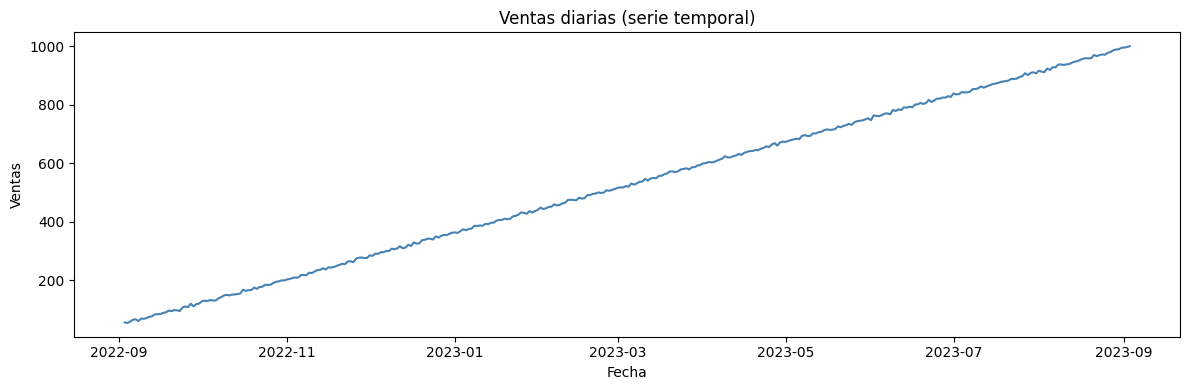

In [29]:
# Análisis de la serie temporal
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=ts, ax=ax, color='steelblue')
ax.set_title('Ventas diarias (serie temporal)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas')
plt.tight_layout()
plt.show()

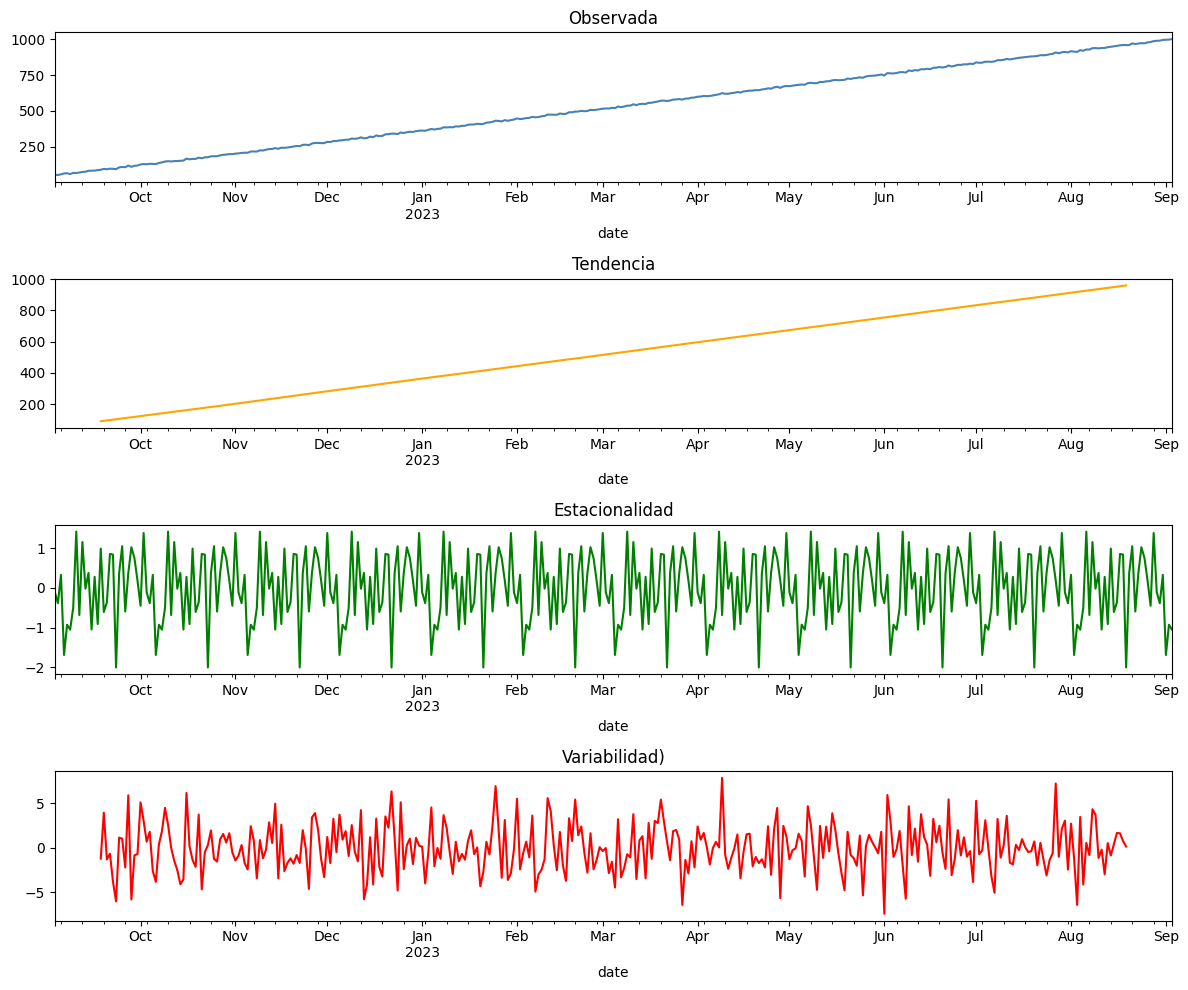

In [30]:
# El tensor es diario: hay una observación por día

decomp = seasonal_decompose(ts, model='additive', period=30)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
decomp.observed.plot(ax=axes[0], title='Observada', color='steelblue')
decomp.trend.plot(ax=axes[1], title='Tendencia', color='orange')
decomp.seasonal.plot(ax=axes[2], title='Estacionalidad', color='green')
decomp.resid.plot(ax=axes[3], title='Variabilidad)', color='red')
plt.tight_layout()
plt.show()

La tendencia es ascendente y sostenida.
La variabilidad es moderada y uniforme a lo largo del tiempo, sin picos extremos ni hay outliers evidentes.

In [20]:
# Test de estacionariedad
def test_stationarity(series, label=''):
    result = adfuller(series, autolag='AIC')
    print(f'=== Dickey-Fuller: {label} ===')
    print(f'  Test Statistic : {result[0]:.4f}')
    print(f'  p-value        : {result[1]:.6f}')
    print(f'  → {"ESTACIONARIA" if result[1] < 0.05 else "NO ESTACIONARIA"}')

test_stationarity(ts, 'Serie original')

=== Dickey-Fuller: Serie original ===
  Test Statistic : 0.5454
  p-value        : 0.986190
  → NO ESTACIONARIA


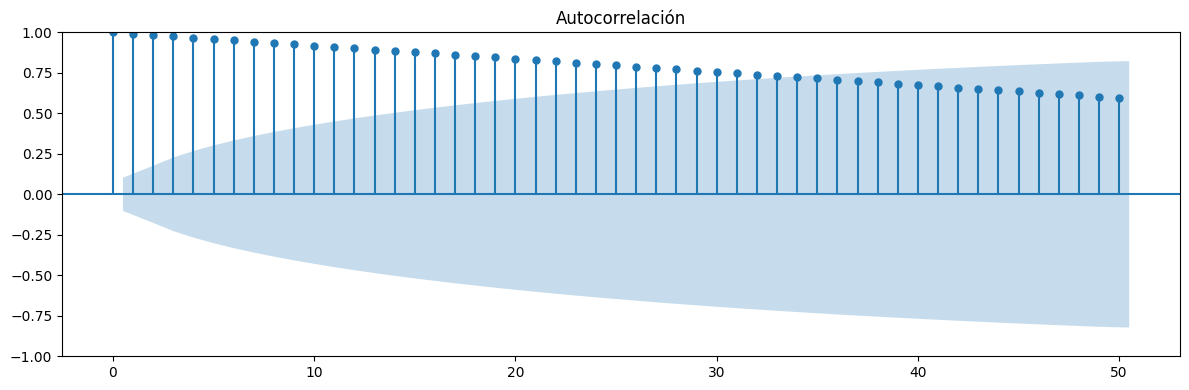

In [31]:
# Autocorrelación
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(ts, lags=50, ax=ax)
ax.set_title('Autocorrelación')
plt.tight_layout()
plt.show()

La autocorrelación es muy alta y decrece lentamente: cada día depende fuertemente de los días anteriores.

In [32]:
# Entranamiento modelo ARIMA
# Diferenciar la serie para hacerla estacionaria
ts_diff = ts.diff().dropna()
test_stationarity(ts_diff, 'Serie diferenciada')

=== Dickey-Fuller: Serie diferenciada ===
  Test Statistic : -9.4303
  p-value        : 0.000000
  → ESTACIONARIA


In [33]:
# Split train/test 80-20
split = int(len(ts_diff) * 0.8)
train = ts_diff[:split]
test  = ts_diff[split:]

print(f'Train: {len(train)} días | Test: {len(test)} días')

Train: 292 días | Test: 73 días


In [34]:
# Auto ARIMA — busca los mejores parámetros p, d, q automáticamente
model = auto_arima(train, seasonal=False, trace=True, stepwise=True)
model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.39 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1773.606, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1771.341, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1772.993, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1748.750, Time=0.02 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=1707.777, Time=0.02 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=1678.260, Time=0.06 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=1649.439, Time=0.07 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=inf, Time=0.43 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=inf, Time=0.45 sec
 ARIMA(5,0,0)(0,0,0)[0] intercept   : AIC=1523.461, Time=0.20 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=1527.694, Time=0.10 sec
 ARIMA(5,0,1)(0,0,0)[0] intercept   : AIC=1490.197, Time=0.56 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=1488.875, Time=0.52 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=1487.9

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  292
Model:               SARIMAX(0, 0, 2)   Log Likelihood                -738.053
Date:                Fri, 29 May 2026   AIC                           1484.105
Time:                        15:03:04   BIC                           1498.812
Sample:                    09-04-2022   HQIC                          1489.996
                         - 06-22-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.5995      0.013    196.950      0.000       2.574       2.625
ma.L1         -1.0184      0.055    -18.664      0.000      -1.125      -0.911
ma.L2          0.0892      0.055      1.632      0.103      -0.018       0.196
sigma2         9.1169      0.818     11.144      0.000       7.513      10.720
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.10
Prob(Q):                              0.98   Prob(JB):                         0.58
Heteroskedasticity (H):               0.99   Skew:                             0.05
Prob(H) (two-sided):                  0.98   Kurtosis:                         2.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

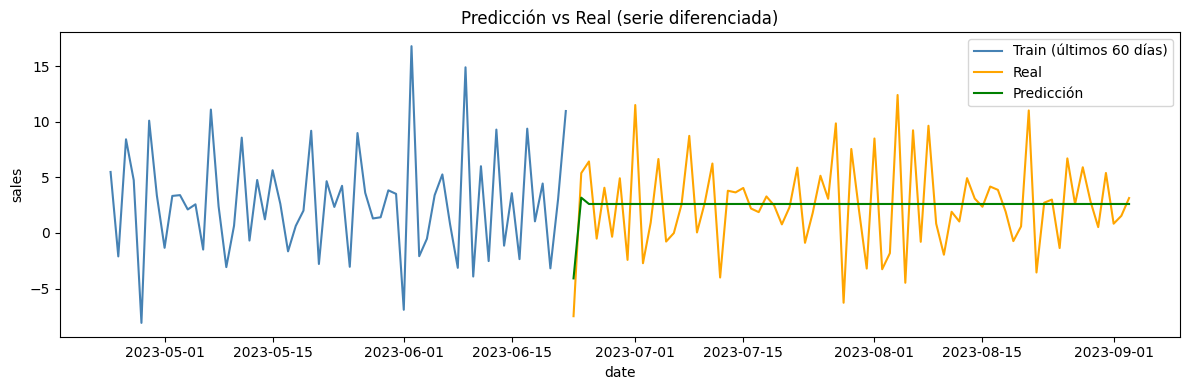

In [35]:
# Predecir sobre el conjunto de test
forecast = model.predict(n_periods=len(test))
forecast_series = pd.Series(forecast, index=test.index)

# Visualización: real vs predicción
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=train[-60:], ax=ax, label='Train (últimos 60 días)', color='steelblue')
sns.lineplot(data=test, ax=ax, label='Real', color='orange')
sns.lineplot(data=forecast_series, ax=ax, label='Predicción', color='green')
ax.set_title('Predicción vs Real (serie diferenciada)')
plt.tight_layout()
plt.show()

In [36]:
# Métricas de rendimiento
mae  = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print(f'MAE  (Error Absoluto Medio)    : {mae:.4f}')
print(f'RMSE (Raíz del Error Cuadrático): {rmse:.4f}')

MAE  (Error Absoluto Medio)    : 3.0221
RMSE (Raíz del Error Cuadrático): 3.9143


In [37]:
# Guardar el modelo
with open('../models/arima_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print('Modelo guardado como arima_model.pkl ✓')

Modelo guardado como arima_model.pkl ✓
